# **Demand Forecasting - Regression Model**

This regression model aims to predict the popularity of a listing using reviews_per_month or number_of_reviews_ltm (Last Twelve Months) as a proxy for demand.

The ["Airbnb Listings: NYC, London, Paris, Tokyo & More"](https://www.kaggle.com/datasets/darkmatternet/airbnb-listings-nyc-london-paris-tokyo-and-more) was obtained from Kaggle aswell.



# 1. Sourcing and loading
* Import relevant libraries
* Load the data
* Exploring the data
* Choosing a dependent variable





**1.a. Import relevant libraries**

In [496]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings # for handling error messages

# to supress warnings that may occur
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

**1.b. Import CSV File**

In [ ]:
url = "https://raw.githubusercontent.com/verahjd/regression_airbnb_listings/blob/main/data/airbnb_top_cities.csv"
df = pd.read_csv(url)

/tmp/ipykernel_2284/2587637459.py:1: DtypeWarning: Columns (4,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/airbnb_top_cities.csv')


**1.c. Exploring Data**

In [498]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city,scrape_date
0,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56861,-0.11270,Private room,70.0,1,55,2025-08-21,0.30,2,331,10,NaN,London,2026-03-29
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48780,-0.16813,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1,NaN,London,2026-03-29
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,NaN,Westminster,51.52195,-0.14094,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0,NaN,London,2026-03-29
3,24328,Battersea live/work artist house,41759,Joe,NaN,Wandsworth,51.47072,-0.16266,Entire home/apt,NaN,7,95,2025-07-05,0.53,1,294,1,NaN,London,2026-03-29
4,36274,Bright 1 bedroom apt off brick lane in Shoreditch,133271,Hendryks,NaN,Tower Hamlets,51.52322,-0.06979,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6,NaN,London,2026-03-29
5,36299,Kew Gardens 3BR house in cul-de-sac,155938,Geert,NaN,Richmond upon Thames,51.48145,-0.28107,Entire home/apt,280.0,3,116,2025-07-20,0.64,1,324,6,NaN,London,2026-03-29
6,36660,You are GUARANTEED to love this,157884,Agri & Roger,NaN,Haringey,51.58478,-0.16057,Private room,90.0,2,730,2025-09-05,4.00,2,289,39,NaN,London,2026-03-29
7,38605,SUNNY ROOM PRIVATE BATHROOM PLUS BREAKFAST,165579,Elisa & Dom,NaN,Hammersmith and Fulham,51.50681,-0.23345,Private room,61.0,2,387,2024-03-11,2.14,3,9,0,NaN,London,2026-03-29
8,38610,Short Term Home,165579,Elisa & Dom,NaN,Hammersmith and Fulham,51.50701,-0.23362,Entire home/apt,340.0,91,42,2023-08-27,0.26,3,317,0,NaN,London,2026-03-29
9,38995,SPACIOUS ROOM IN CONTEMPORARY STYLE FLAT,167281,Cesar,NaN,Southwark,51.47860,-0.06114,Private room,49.0,1,72,2025-07-26,1.06,1,172,16,NaN,London,2026-03-29


In [499]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292802 entries, 0 to 292801
Data columns (total 20 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              292802 non-null  int64  
 1   name                            292802 non-null  object 
 2   host_id                         292802 non-null  int64  
 3   host_name                       292712 non-null  object 
 4   neighbourhood_group             19410 non-null   object 
 5   neighbourhood                   292802 non-null  object 
 6   latitude                        292802 non-null  float64
 7   longitude                       292802 non-null  float64
 8   room_type                       292802 non-null  object 
 9   price                           139950 non-null  float64
 10  minimum_nights                  292802 non-null  int64  
 11  number_of_reviews               292802 non-null  int64  
 12  last_review     

In [500]:
df.shape

(292802, 20)

In [501]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.928020e+05,2.928020e+05,292802.000000,292802.000000,1.399500e+05,292802.000000,292802.000000,226437.000000,292802.000000,292802.000000,292802.000000
mean,6.925516e+17,2.169006e+08,40.009043,21.583817,6.042208e+02,18.515328,31.822187,1.169245,21.022343,162.651423,7.942511
std,5.785082e+17,2.219687e+08,21.677901,43.996214,7.403676e+03,65.016518,73.409545,1.535733,69.392336,139.492379,15.926128
min,2.737000e+03,1.662000e+03,-34.095680,-0.496760,4.000000e+00,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.347211e+07,2.495756e+07,41.878008,-0.066950,9.400000e+01,1.000000,1.000000,0.200000,1.000000,0.000000,0.000000
50%,8.724348e+17,1.180033e+08,48.866320,2.335690,1.630000e+02,2.000000,7.000000,0.630000,2.000000,155.000000,1.000000
75%,1.208697e+18,4.221622e+08,51.495854,12.463966,3.420000e+02,5.000000,29.000000,1.610000,9.000000,304.000000,9.000000
max,1.518168e+18,7.206394e+08,52.425120,151.340140,1.085147e+06,1125.000000,5097.000000,99.420000,816.000000,365.000000,1304.000000


In [502]:
df.isna().sum()

,0
id,0
name,0
host_id,0
host_name,90
neighbourhood_group,273392
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,152852


**1.e. Choosing a dependent variable**

Since we hope to determine the popularity of a listing by using factors that drive the most booking, we'll select *'reviews_per_month'* as a target variable.

This variable is also a float/contiuous variable, making it the best candidate for the regression analysis.

Let's futher understand the variable with visualizations.

Text(0.5, 1.0, 'Histogram of Reviews per Month')

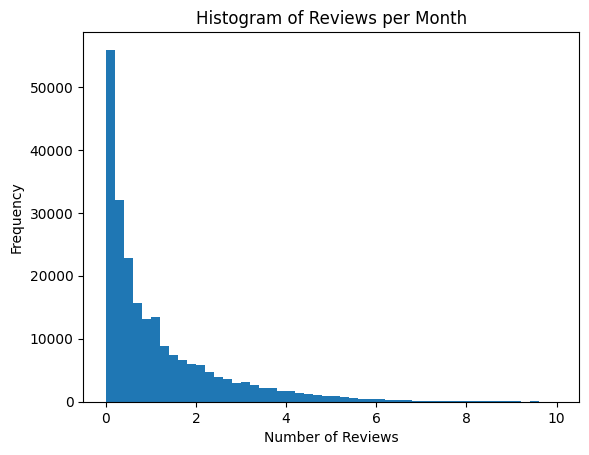

In [503]:
plt.hist(df['reviews_per_month'].dropna(), bins=50, range = [0,10])
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.title('Histogram of Reviews per Month')

*Note:* 'reviews_per_month' refers to the average frequency of reviews per month since the listing first went live

In [504]:
df['reviews_per_month'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 292802 entries, 0 to 292801
Series name: reviews_per_month
Non-Null Count   Dtype  
--------------   -----  
226437 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [505]:
df['reviews_per_month'].describe()

,reviews_per_month
count,226437.000000
mean,1.169245
std,1.535733
min,0.010000
25%,0.200000
50%,0.630000
75%,1.610000
max,99.420000


The histogram shows a max x-variable of 99.41 while the average is only 1.16. Meaning there are outliers in the dataset. We will have to normalize this later on.

The frequencies are indicators of how often the listing is being booked/reviewed.

*Example: the highest average of 99.41 indicates how the listing's been reviewed at an average of 99.41 times in a month*

#2. Clean, Transforming and Visualizing

With our selected independent variable, clean up the dataset.

**2.1. Handle Missing Data**

In [506]:
df['reviews_per_month'].isna().sum()

np.int64(66365)

In [507]:
df = df.dropna(subset=['reviews_per_month'])

In [508]:
# confirm the null values were removed

df.shape

(226437, 20)

In [509]:
rows_remain = 292802 - 226437
print(f'Number of rows removed: ' + str(rows_remain))

Number of rows removed: 66365


same with the price column

In [510]:
df['price'].isna().sum()

np.int64(115990)

In [511]:
df = df.dropna(subset=['price'])

**2.2. Removing Unneccessary Columns**

Next, lets remove columns that won't help with the prediction such as:

* id
* host_id
* name
* host_name

license also has too many missing values so we'll remove that aswell

In [512]:
df.drop(columns = ['id','host_id','name','host_name','license'], inplace=True)

In [513]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,scrape_date
0,NaN,Islington,51.56861,-0.11270,Private room,70.0,1,55,2025-08-21,0.30,2,331,10,London,2026-03-29
1,NaN,Kensington and Chelsea,51.48780,-0.16813,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1,London,2026-03-29
2,NaN,Westminster,51.52195,-0.14094,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0,London,2026-03-29
4,NaN,Tower Hamlets,51.52322,-0.06979,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6,London,2026-03-29
5,NaN,Richmond upon Thames,51.48145,-0.28107,Entire home/apt,280.0,3,116,2025-07-20,0.64,1,324,6,London,2026-03-29


**2.3. Transforming: Normalizing Dataset**

Since the 'reviews_per_month' variable has an outlier that's important to the analysis ( handle right-skewed data) , instead of removing it, we'll do [**Log Transformation**](https://www.geeksforgeeks.org/python/log-and-natural-logarithmic-value-of-a-column-in-pandas-python/)

In [514]:
# apply log transformation to the data
df['reviews_per_month'] = np.log(df['reviews_per_month'])

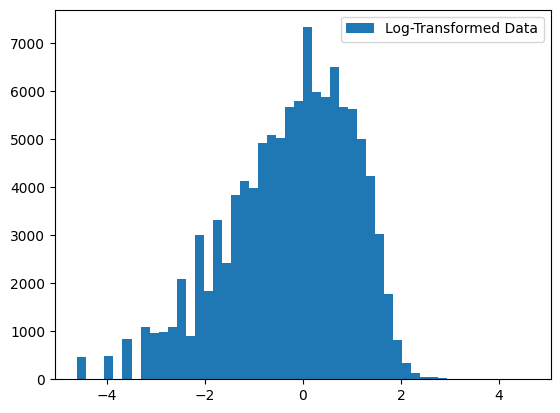

In [515]:
# plot log-transformed data
plt.hist(df['reviews_per_month'], bins=50, label='Log-Transformed Data')
plt.legend()
plt.show()

**2.4. Visualize Data Correlations**

In [516]:
# select only numerical columns
numeric_df = df.select_dtypes(include='number')

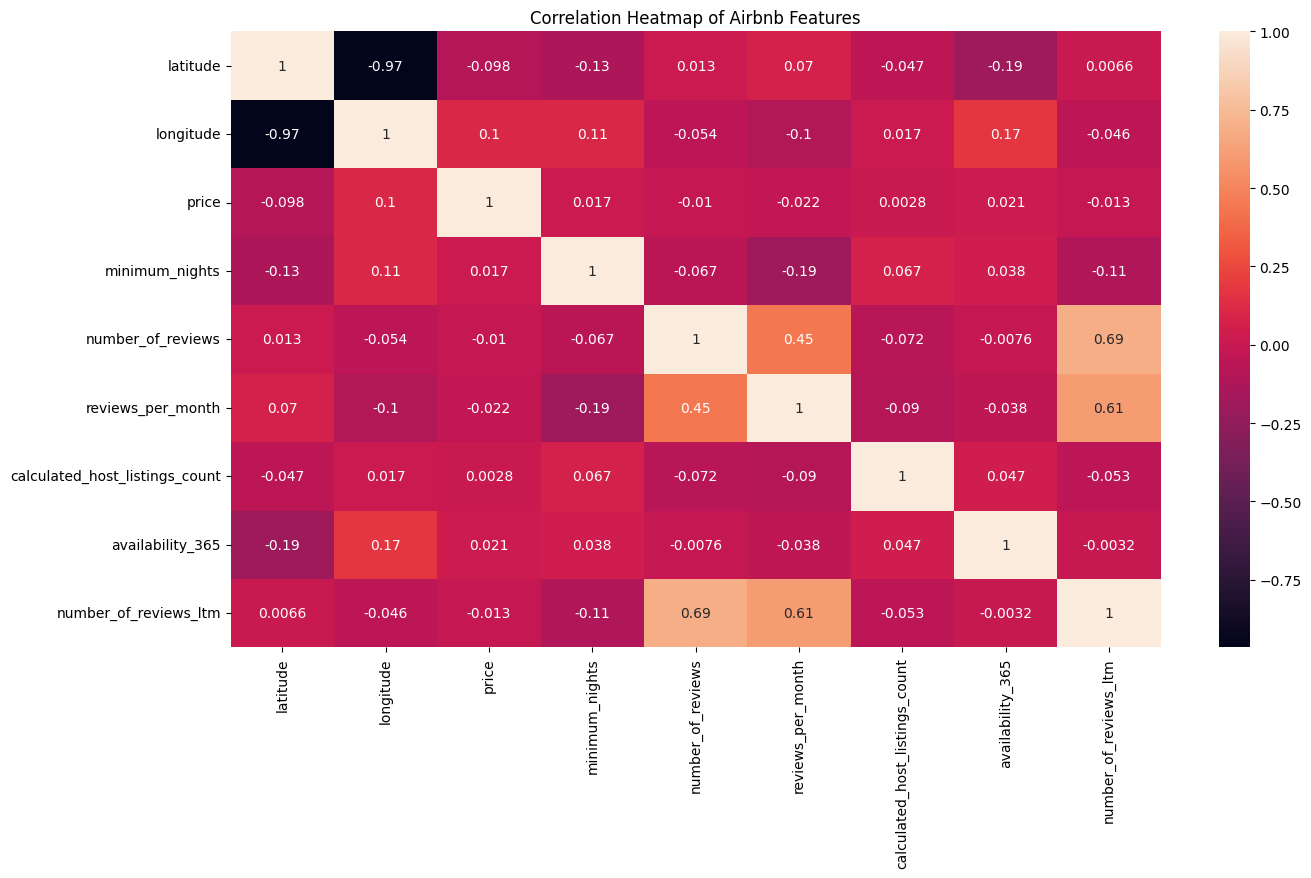

In [517]:
# create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(numeric_df.corr(), annot =True)
plt.title('Correlation Heatmap of Airbnb Features')
plt.show()

*Note: closer to 1 = strong positive correlation, closer to -1 = stronger negative correlation, closer to 0 = weak correlation*

In [518]:
numeric_df.corr()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
latitude,1.000000,-0.965876,-0.097678,-0.126040,0.012544,0.069660,-0.047392,-0.191214,0.006640
longitude,-0.965876,1.000000,0.103794,0.108574,-0.054080,-0.100703,0.016509,0.172064,-0.045551
price,-0.097678,0.103794,1.000000,0.016551,-0.010317,-0.022480,0.002797,0.020777,-0.012602
minimum_nights,-0.126040,0.108574,0.016551,1.000000,-0.067305,-0.185878,0.067253,0.037995,-0.108570
number_of_reviews,0.012544,-0.054080,-0.010317,-0.067305,1.000000,0.446351,-0.071624,-0.007550,0.688916
reviews_per_month,0.069660,-0.100703,-0.022480,-0.185878,0.446351,1.000000,-0.090339,-0.037851,0.606577
calculated_host_listings_count,-0.047392,0.016509,0.002797,0.067253,-0.071624,-0.090339,1.000000,0.047124,-0.053290
availability_365,-0.191214,0.172064,0.020777,0.037995,-0.007550,-0.037851,0.047124,1.000000,-0.003201
number_of_reviews_ltm,0.006640,-0.045551,-0.012602,-0.108570,0.688916,0.606577,-0.053290,-0.003201,1.000000


Now that the heatmap is generated, I can select the independent variables for the regression model.

**Selected features:** price, minimun_nights, availability_365, calculated_host_listings_count, room_type, city

Even though number_of_reviews and number_of_reviews_ltm show high correlation, we cannot include them because it's essentially the same as our target variable (reviews_per_month)


**2.5. Create the dummy features**



In [519]:
# Create dummy features for 'city' and 'room_type'
df = pd.get_dummies(df, columns=['city', 'room_type'], drop_first=True, dtype=int)

# Verify the new columns
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,scrape_date,city_Bangkok,city_Barcelona,city_London,city_Rome,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,NaN,Islington,51.56861,-0.11270,70.0,1,55,2025-08-21,-1.203973,2,331,10,2026-03-29,0,0,1,0,0,1,0
1,NaN,Kensington and Chelsea,51.48780,-0.16813,149.0,4,97,2025-04-05,-0.673345,1,199,1,2026-03-29,0,0,1,0,0,0,0
2,NaN,Westminster,51.52195,-0.14094,411.0,3,56,2024-02-19,-1.139434,2,80,0,2026-03-29,0,0,1,0,0,0,0
4,NaN,Tower Hamlets,51.52322,-0.06979,210.0,5,15,2025-09-06,-2.407946,2,323,6,2026-03-29,0,0,1,0,0,0,0
5,NaN,Richmond upon Thames,51.48145,-0.28107,280.0,3,116,2025-07-20,-0.446287,1,324,6,2026-03-29,0,0,1,0,0,0,0


In [521]:
# Get all dummy column names for city and room_type
city_dummies = [col for col in df.columns if col.startswith('city_')]
room_type_dummies = [col for col in df.columns if col.startswith('room_type_')]

# 3. Modeling

**3.1. Train/Test Split**

In [522]:
# subsetting data to the independent and dependent variables
X = df[['price', 'minimum_nights', 'calculated_host_listings_count', 'availability_365'] + city_dummies + room_type_dummies]

y = df[['reviews_per_month']]

# split the test fata
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [523]:
# check train/tesy split
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(82835, 11) (27612, 11)
(82835, 1) (27612, 1)


**3.2. Making a Multiple Linear Regression Model**

In [549]:
# Create and train the model using sklearn
reg_model = linear_model.LinearRegression()
reg_model.fit(X_train, y_train)

LinearRegression()

In [550]:
# Evaluate the model
print("R² (train):", reg_model.score(X_train, y_train))

R² (train): 0.0742266757963349


The above score is called R-Squared coefficient, or the "coefficient of determination". It's basically a measure of how successfully our model predicts the variations in the data away from the mean: 1 would mean a perfect model that explains 100% of the variation.

In [551]:
# Use reg_model.predict()
y_pred = reg_model.predict(X_test)

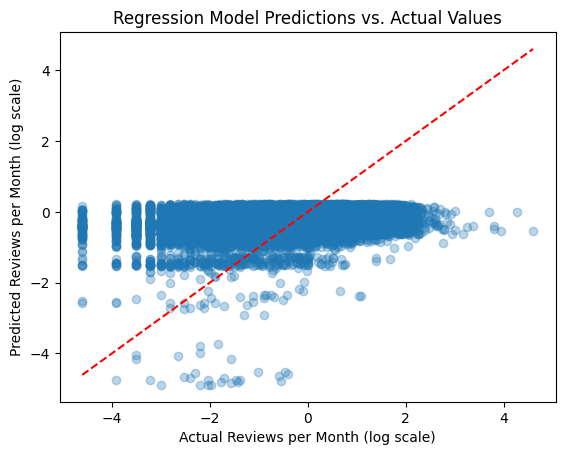

In [552]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.title("Regression Model Predictions vs. Actual Values")
plt.xlabel("Actual Reviews per Month (log scale)")
plt.ylabel("Predicted Reviews per Month (log scale)")
plt.show()

# 4. Findings and Conclusion

**4.1. Model Performance**

The multiple linear regression model was trained on listings across 7 major cities (London, Paris, Rome, Bangkok,
Barcelona, Sydney, and Amsterdam).

The model achieved an **R² score of 0.074**, meaning that the selected features
explain approximately **7.4% of the variance** in listing reviews per month.
While this is a low score, it is an informative finding in itself.

**4.2. What This Tells Us**

The low R² suggests that **listing characteristics such as price, room type,
city, minimum nights, and availability alone are not strong predictors of
review frequency**. This makes intuitive sense — a listing's popularity is
likely driven more by factors not captured in this dataset, such as:

- Quality and quantity of listing photos
- Host responsiveness and communication
- Guest experience and word-of-mouth
- Seasonal trends and local events
- Listing description and amenities

**4.3. Limitations**

- **Indirect target variable:** `reviews_per_month` was used as a proxy for
  demand, but not all guests leave reviews, so it does not perfectly represent
  actual booking frequency.

- **Weak feature correlations:** As observed in the correlation heatmap, most
  selected features had near-zero correlation with the target variable, limiting
  the model's predictive power.

- **Linear assumption:** Linear regression assumes a straight-line relationship
  between features and the target. Real-world booking behavior may follow
  non-linear patterns that this model cannot capture.

**4.4. Future Work**

To improve model performance, future iterations of this project could explore:

1. **Non-linear models** such as Random Forest or XGBoost, which may better
   capture complex relationships in the data
2. **Additional features** such as neighbourhood, listing descriptions, or
   host ratings
3. **A different target variable** such as `price`, which tends to be more
   predictable from listing characteristics
4. **NLP analysis** on listing titles and descriptions to extract sentiment
   or quality signals

## 4.5. Conclusion

Despite the model's modest predictive performance, this project successfully
demonstrated a full end-to-end regression pipeline — from data sourcing and
cleaning, to feature engineering, visualization, and model evaluation.

The findings suggest that predicting Airbnb listing popularity is a complex
problem that goes beyond basic listing attributes, and that more sophisticated
approaches and richer data would be needed to build a truly accurate demand
forecasting model.